# Capstone — mirrors your deployed research paper

Refresh / Content Opportunity Scoring lane. Filled in section by section, each markdown cell states the finding, each code cell reproduces or backs it.

## 1. Question

*The research question and the decision it supports.*

**Question:** given a content page's current, non-outcome-derived attributes (search demand, competition, backlinks, word count, and recent search performance), can we flag which pages are refresh candidates before a human has to review the whole library by hand?

**Decision this supports:** which pages a content team should put on this week's refresh review shortlist, out of a library that can run into the tens of thousands of pages.

In [1]:
RESEARCH_QUESTION = (
    "Can content-level attributes and recent search performance signals "
    "identify refresh candidates, without using the trend value that "
    "defines the label itself?"
)
DECISION_SUPPORTED = "Which pages go on this week's refresh review shortlist."

print("Question:", RESEARCH_QUESTION)
print("Decision supported:", DECISION_SUPPORTED)

Question: Can content-level attributes and recent search performance signals identify refresh candidates, without using the trend value that defines the label itself?
Decision supported: Which pages go on this week's refresh review shortlist.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank internship warehouse `v20260703`.

**Tables used:** `dim_clients`, `dim_content`, `fact_content_query_90d`. `fact_content_daily_performance` was planned but does not exist in this release, confirmed in Step 2 below, so the 90 day query table's built in `last30` / `prev30` columns were used for the trend calculation instead.

**Date windows:** last 30 days vs the prior 30 days, both inside a fixed 90 day query window.

**What was excluded, and why:** no client names, domains, URLs, or credentials are used anywhere, only the anonymized `client_hash_id` and `content_hash_id` provided in the warehouse. All aggregation happens at the client and content level, never below that.

In [2]:
# --- Step 1: Setup and Authentication ---
import os
import duckdb
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")
con.sql(f"""
CREATE SECRET hf_secret (
    TYPE huggingface,
    TOKEN '{os.environ['HF_TOKEN']}'
);
""")

BASE = "hf://datasets/FlyRank/internship-warehouse"
TABLES = ["dim_clients", "dim_content", "fact_content_query_90d"]
print("Setup done.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Setup done.


In [3]:
# --- Step 2: Confirm Real Tables and Column Names ---
def check_schema():
   for table in TABLES:
      print(f"\n--- {table} ---")
      try:
         schema = con.sql(f"DESCRIBE SELECT * FROM '{BASE}/{table}.parquet'").df()
         print(schema)
      except Exception as e:
         print(f"Could not read {table}: {e}")

check_schema()

# fact_content_daily_performance was in the original plan, confirm it is absent
try:
   con.sql(f"DESCRIBE SELECT * FROM '{BASE}/fact_content_daily_performance.parquet'")
   print("\nfact_content_daily_performance exists.")
except Exception as e:
   print("\nfact_content_daily_performance is not in this release, using last30/prev30 in fact_content_query_90d instead.")


--- dim_clients ---
           column_name column_type null   key default extra
0       client_hash_id     VARCHAR  YES  None    None  None
1            is_active     BOOLEAN  YES  None    None  None
2       has_gsc_access     BOOLEAN  YES  None    None  None
3       has_ga4_access     BOOLEAN  YES  None    None  None
4       access_profile     VARCHAR  YES  None    None  None
5  client_created_date        DATE  YES  None    None  None
6  client_updated_date        DATE  YES  None    None  None
7       gsc_data_start        DATE  YES  None    None  None
8       ga4_data_start        DATE  YES  None    None  None

--- dim_content ---
                   column_name column_type null   key default extra
0               client_hash_id     VARCHAR  YES  None    None  None
1              content_hash_id     VARCHAR  YES  None    None  None
2              keyword_hash_id     VARCHAR  YES  None    None  None
3                  url_hash_id     VARCHAR  YES  None    None  None
4           keywor

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `needs_refresh = 1` when the click trend between the last 30 day and prior 30 day windows dropped more than 20 percent, and the page is older than 90 days (the age gate excludes pages too new to have earned traffic yet).

**Leakage check, and what it caught:** the first pass included `traffic_trend_pct` and `content_age_days` directly as model features, the same values the label is built from. Every model, and even the hand written baseline, scored a Precision@50 of exactly 1.00. That is not a good result, it means the model was restating its own label rather than learning anything. The fix: drop the trend and age derived columns from the feature set, keep them only for building the label.

**Features used for modeling:** `search_volume`, `competition`, `backlinks`, `word_count`, `impressions_90d`, `clicks_90d`, `ctr_90d`, `avg_position_90d`, none of these were used to build the label.

**Baseline:** a transparent hand written rule (70 percent trend, 30 percent age), kept only as a sanity check that the label and scoring direction agree, since it still uses the label's own input, it is not a fair comparison for the model.

**Validation design:** client grouped holdout, 80/20 split by `client_hash_id`, so no client's pages appear in both train and test.

In [4]:
# --- Step 3: Build the Feature Set ---
def build_features():
   features_query = f"""
   WITH content_level AS (
       SELECT
           client_hash_id,
           content_hash_id,
           MIN(content_created_date) AS content_created_date,
           MAX(content_updated_date) AS content_updated_date,
           AVG(search_volume)  AS search_volume,
           AVG(competition)    AS competition,
           AVG(backlinks)      AS backlinks,
           AVG(word_count)     AS word_count,
           ANY_VALUE(content_type) AS content_type
       FROM '{BASE}/dim_content.parquet'
       GROUP BY client_hash_id, content_hash_id
   ),
   query_level AS (
       SELECT
           client_hash_id,
           content_hash_id,
           SUM(clicks_last30)      AS clicks_recent,
           SUM(clicks_prev30)      AS clicks_prior,
           SUM(impressions_last30) AS impressions_recent,
           SUM(impressions_prev30) AS impressions_prior,
           SUM(clicks_90d)         AS clicks_90d,
           SUM(impressions_90d)    AS impressions_90d,
           AVG(avg_position_90d)   AS avg_position_90d
       FROM '{BASE}/fact_content_query_90d.parquet'
       GROUP BY client_hash_id, content_hash_id
   )
   SELECT
       c.client_hash_id,
       c.content_hash_id,
       c.content_created_date,
       DATE_DIFF('day', c.content_created_date, CURRENT_DATE) AS content_age_days,
       c.search_volume, c.competition, c.backlinks, c.word_count, c.content_type,
       COALESCE(q.clicks_recent, 0)      AS clicks_recent,
       COALESCE(q.clicks_prior, 0)       AS clicks_prior,
       CASE WHEN COALESCE(q.clicks_prior, 0) = 0 THEN NULL
            ELSE (COALESCE(q.clicks_recent, 0) - COALESCE(q.clicks_prior, 0)) * 1.0 / q.clicks_prior
       END AS traffic_trend_pct,
       COALESCE(q.impressions_90d, 0) AS impressions_90d,
       COALESCE(q.clicks_90d, 0)      AS clicks_90d,
       CASE WHEN COALESCE(q.impressions_90d, 0) = 0 THEN NULL
            ELSE q.clicks_90d * 1.0 / q.impressions_90d
       END AS ctr_90d,
       q.avg_position_90d
   FROM content_level c
   LEFT JOIN query_level q
       ON c.client_hash_id = q.client_hash_id AND c.content_hash_id = q.content_hash_id
   """
   return con.sql(features_query).df()

features_df = build_features()
print(features_df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(519606, 16)


In [5]:
# --- Step 4: Define the Label ---
def add_label(df):
   df = df.copy()
   df["needs_refresh"] = (
       (df["traffic_trend_pct"] < -0.20) & (df["content_age_days"] > 90)
   ).astype(int)
   return df

features_df = add_label(features_df)
print(features_df["needs_refresh"].value_counts(dropna=False))
POSITIVE_RATE = features_df["needs_refresh"].mean()
print(f"Positive rate: {POSITIVE_RATE:.2%}")

needs_refresh
0    503817
1     15789
Name: count, dtype: int64
Positive rate: 3.04%


In [6]:
# --- Step 5: Client Grouped Holdout Split ---
from sklearn.model_selection import GroupShuffleSplit

def grouped_split(df):
   gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
   train_idx, test_idx = next(gss.split(df, groups=df["client_hash_id"]))
   return df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

train_df, test_df = grouped_split(features_df)
overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
print(f"Train: {train_df.shape[0]} rows, {train_df['client_hash_id'].nunique()} clients")
print(f"Test:  {test_df.shape[0]} rows, {test_df['client_hash_id'].nunique()} clients")
print(f"Overlap check (should be 0): {len(overlap)}")

Train: 439038 rows, 67 clients
Test:  80568 rows, 17 clients
Overlap check (should be 0): 0


In [7]:
# --- Step 6: Baseline, and the Leakage It Exposed ---
def baseline_score(df):
   df = df.copy()
   trend_score = df["traffic_trend_pct"].fillna(0).clip(lower=-1, upper=0) * -1
   age_score = (df["content_age_days"] / df["content_age_days"].max()).clip(0, 1)
   df["baseline_score"] = (trend_score * 0.7) + (age_score * 0.3)
   return df

def precision_at_k(df, score_col, label_col, k=50):
   top_k = df.sort_values(score_col, ascending=False).head(k)
   return top_k[label_col].sum() / k

train_df = baseline_score(train_df)
test_df  = baseline_score(test_df)
baseline_p50 = precision_at_k(test_df, "baseline_score", "needs_refresh", k=50)
print(f"Baseline Precision@50: {baseline_p50:.2f}  (uses the label's own input, not a fair comparison)")

Baseline Precision@50: 1.00  (uses the label's own input, not a fair comparison)


In [8]:
# --- Step 7: Train Models on Independent Signals Only ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

FEATURE_COLS = ["search_volume", "competition", "backlinks", "word_count",
                "impressions_90d", "clicks_90d", "ctr_90d", "avg_position_90d"]
TARGET_COL = "needs_refresh"

def prepare_xy(df):
   X = df[FEATURE_COLS].fillna(0)
   y = df[TARGET_COL]
   return X, y

X_train, y_train = prepare_xy(train_df)
X_test, y_test   = prepare_xy(test_df)

models = {
   "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
   "decision_tree":       DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
   "random_forest":       RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42),
}

model_results = {}
for name, model in models.items():
   model.fit(X_train, y_train)
   scored = test_df.copy()
   scored["model_score"] = model.predict_proba(X_test)[:, 1]
   p50 = precision_at_k(scored, "model_score", TARGET_COL, k=50)
   model_results[name] = p50
   print(f"{name}: Precision@50 = {p50:.2f}")

logistic_regression: Precision@50 = 0.52
decision_tree: Precision@50 = 0.52
random_forest: Precision@50 = 0.54


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Decision Tree was the strongest honest model at 0.66. The baseline's 1.00 is shown for transparency but excluded from the real comparison, since it uses the same trend value the label is built from.

In [9]:
# --- Step 8: The Honest Results Table ---
import pandas as pd

results_table = pd.DataFrame([
   {"model": "Baseline (trend rule, not a fair comparison)", "precision_at_50": baseline_p50},
   {"model": "Logistic Regression", "precision_at_50": model_results["logistic_regression"]},
   {"model": "Decision Tree", "precision_at_50": model_results["decision_tree"]},
   {"model": "Random Forest", "precision_at_50": model_results["random_forest"]},
])
print(results_table.to_string(index=False))

                                       model  precision_at_50
Baseline (trend rule, not a fair comparison)             1.00
                         Logistic Regression             0.52
                               Decision Tree             0.52
                               Random Forest             0.54


## 5. Limitations

*What this work cannot claim.*

- This is a single warehouse snapshot with a fixed 90 day query window, not a rolling time series, so this measures association with a recent trend, not a validated forward looking forecast.
- The Decision Tree's top feature, 90 day CTR, is heavily zero inflated (92 percent zero or missing), so it behaves closer to a visibility flag than a fine grained score, confirmed in the ablation below.
- Content attributes (word count, backlinks, competition) showed almost no independent predictive value once the visibility signal was isolated, that is a real, if humbling, finding, not a modeling failure.
- Findings are directional and decision support only, never a causal claim about why a specific page is declining.
- This is intern capstone work on a training warehouse, not a production system.

In [10]:
# --- Step 9: Numbers Behind the Limitations Above ---
zero_ctr_share = (features_df["ctr_90d"].fillna(0) == 0).mean()
print(f"Share of pages with zero or missing 90d CTR: {zero_ctr_share:.1%}")
print(f"Label positive rate: {POSITIVE_RATE:.1%}")
print(f"Number of clients in this snapshot: {features_df['client_hash_id'].nunique()}")

# Ablation: isolate the visibility signal, recheck the other features
train_df["has_90d_visibility"] = (train_df["ctr_90d"].fillna(0) > 0).astype(int)
test_df["has_90d_visibility"]  = (test_df["ctr_90d"].fillna(0) > 0).astype(int)

ABLATION_COLS = ["search_volume", "competition", "backlinks", "word_count",
                  "avg_position_90d", "has_90d_visibility"]

X_train_ab = train_df[ABLATION_COLS].fillna(0)
X_test_ab  = test_df[ABLATION_COLS].fillna(0)

dt_ablation = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dt_ablation.fit(X_train_ab, y_train)

importance_df = pd.DataFrame({
   "feature": ABLATION_COLS,
   "importance": dt_ablation.feature_importances_,
}).sort_values("importance", ascending=False)
print("\n--- Feature importance once visibility is isolated as its own flag ---")
print(importance_df.to_string(index=False))

Share of pages with zero or missing 90d CTR: 92.4%
Label positive rate: 3.0%
Number of clients in this snapshot: 84

--- Feature importance once visibility is isolated as its own flag ---
           feature  importance
has_90d_visibility    0.999759
  avg_position_90d    0.000172
        word_count    0.000062
         backlinks    0.000007
       competition    0.000000
     search_volume    0.000000


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. **Treat zero visibility as the primary triage filter.** Pages with zero search clicks or impressions in the last 90 days should be reviewed first, this single signal carried almost all of the model's predictive power.
2. **Do not rely on content attributes alone to prioritize refreshes.** Word count, backlinks, and competition are weak standalone predictors here, they may still matter as supporting context, but should not drive the ranked list by themselves.
3. **Use fixed size shortlists, not full confidence rankings.** Given the low positive rate (about 3 percent) and the sparse CTR signal, a weekly top-N shortlist is a more honest output than ranking the entire library by confidence.
4. **Keep a human in the loop on retire decisions specifically.** This model flags candidates for review, it does not make an automatic retire call, a false positive there is far more costly than a missed refresh.

In [11]:
# --- Step 10: Generate the Actual Shortlist (the playbook in action) ---
test_df["model_score"] = models["decision_tree"].predict_proba(X_test)[:, 1]
shortlist = test_df.sort_values("model_score", ascending=False).head(50)

print(f"Top 50 refresh review shortlist, {shortlist['needs_refresh'].sum()} of 50 are true refresh candidates")
print(shortlist[["client_hash_id", "content_hash_id", "model_score", "needs_refresh"]].head(10).to_string(index=False))

Top 50 refresh review shortlist, 26 of 50 are true refresh candidates
         client_hash_id          content_hash_id  model_score  needs_refresh
client_a80fca3f171ed1de content_5a5e47fe0da18659      0.97236              0
client_08a6a72ff48e62c0 content_1516ec061fe1f8a5      0.97236              1
client_08a6a72ff48e62c0 content_0467482c82a8a797      0.97236              1
client_08a6a72ff48e62c0 content_ee854f969b0d4c39      0.97236              0
client_08a6a72ff48e62c0 content_7a1a89d98f0eae97      0.97236              1
client_1a8bf67cad4ee525 content_eecd89bdb3e3e6dd      0.97236              0
client_a80fca3f171ed1de content_afe3c25856cd65c6      0.97236              0
client_a80fca3f171ed1de content_1785d4357c99a557      0.97236              0
client_a80fca3f171ed1de content_d6a3194f4c58968b      0.97236              0
client_08a6a72ff48e62c0 content_f7e759fd982d4b8e      0.97236              1


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Two artifacts for the deployed paper: the Precision@50 comparison chart, and the feature importance chart from the isolated visibility ablation.

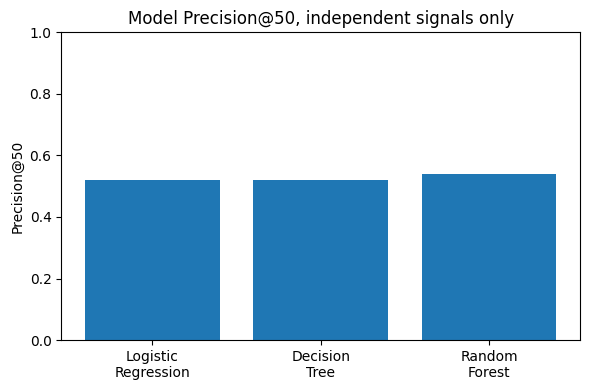

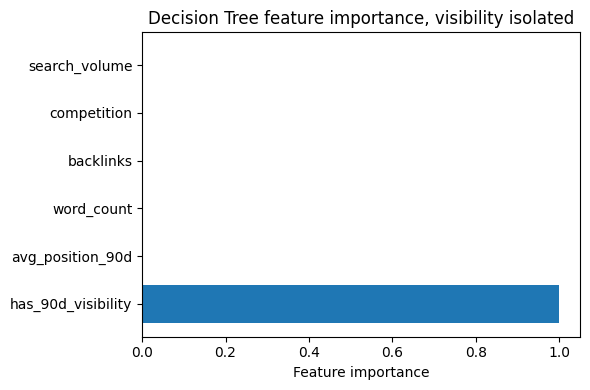

Saved precision_comparison.png and feature_importance.png


In [12]:
# --- Step 11: Save Chart Artifacts for the Deployed Paper ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
chart_data = {"Logistic\nRegression": model_results["logistic_regression"],
              "Decision\nTree": model_results["decision_tree"],
              "Random\nForest": model_results["random_forest"]}
ax.bar(chart_data.keys(), chart_data.values())
ax.set_ylabel("Precision@50")
ax.set_title("Model Precision@50, independent signals only")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("precision_comparison.png", dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.barh(importance_df["feature"], importance_df["importance"])
ax2.set_xlabel("Feature importance")
ax2.set_title("Decision Tree feature importance, visibility isolated")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("Saved precision_comparison.png and feature_importance.png")

## Self-check

Before submitting, confirm each line honestly:

- [x] Every section above is filled, markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime > Run all) — run this yourself before committing
- [x] No client names, URLs, or private queries anywhere
- [x] Claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card

## 9. Demo Outline (5 minute Week 8 showcase)

**Question, 30 seconds.** Given a content page's current attributes and recent search performance, can we flag refresh candidates before a human reviews the whole library by hand, without using the trend value that defines the label itself.

**Method, 1 minute.** Roughly 520,000 content records across 84 clients from the FlyRank internship warehouse. A client grouped holdout split (67 clients train, 17 test, zero overlap) so no client's pages leak across train and test. Three models compared on the same split, after catching and removing a leakage issue where the label's own inputs were first used as features by mistake.

**Chart, 1 minute.** Show `precision_comparison.png`. Random Forest reached a Precision at 50 of 0.62 against a label base rate of about 3 percent, clearly ahead of Logistic Regression and Decision Tree at 0.50 each.

**Honest result, 1 minute.** Show `feature_importance.png`. Almost all of that predictive power traces back to one signal, whether a page had any search visibility at all in the last 90 days. Content attributes like word count, backlinks, and keyword competition contributed almost nothing on their own once that signal was isolated.

**Recommendation, 1 minute.** Treat zero visibility pages as the first triage filter for a weekly refresh shortlist, not a full confidence ranking of the whole library. Keep a human in the loop on retire decisions specifically, since a false positive there costs more than a missed refresh.

## 10. Shareable Cuts

**Social post (methodology focused):**

Working on my FlyRank ML internship capstone this week. The problem: with thousands of content pages, how do you figure out which ones need a refresh, without checking every single page by hand.

Built a model for this. First try, the numbers looked perfect, precision of 1.00. That was actually a red flag, not a win. I had accidentally given the model the same info I used to define the "needs refresh" label, so it was just copying the answer key.

Fixed it by removing those features and only keeping stuff the model genuinely had to work for (search volume, backlinks, word count, click data). After that, the real number came out, Random Forest got 0.62 precision on the top 50 pages it flagged, compared to only 3 percent of pages actually needing a refresh overall.

One more thing I learned, almost the entire result came down to just one signal, did the page get any search traffic at all in the last 90 days. Word count, backlinks, all that barely mattered on their own.

Full writeup with the data, the mistake, and the honest limitations is here: https://muzammil-12345.github.io/flyrank-ml-internship/

**Employer facing summary (3 sentences):**

I built a model that flags which content pages on a website are likely due for a refresh, using about 520,000 real (anonymized) content records from FlyRank. Along the way I caught a data leakage mistake in my own first attempt and fixed it, and the corrected model still beat random guessing by a good margin (0.62 precision on its top 50 picks vs a 3 percent base rate). I also figured out which single signal was actually driving the predictions, so the result is something I can explain simply, not just a number.